## **This notebook functions to assess alterations in right amygdala functional connectivity during the treatment process.**

In [1]:
# Import core data science libraries
import pandas as pd
import numpy as np
import os,re
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Random effects covariance is singular")
import seaborn as sns
sns.set(font_scale=1.5,style="white")
import matplotlib.pyplot as plt
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
import matplotlib.patches as mpatches
# Statistical functions for correlations, non-parametric tests, and z-score normalization
from scipy.stats import pearsonr,wilcoxon,ttest_rel,ttest_ind,zscore
from tqdm import tqdm
import ptitprince as pt
import matplotlib.pyplot as plt
# Custom color palette for responder groups
res_colors = ['#E6194B','#4363D8']


In [2]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Apply FDR (Benjamini-Hochberg) correction to a list of p-values
def FDR_correct(p_values):
    return sm.stats.multipletests(p_values, alpha=0.05, method='fdr_bh')[1]

# Convert p-value to significance stars (ns, *, **, ***)
def p_star(p):
    if(p>0.05 or p==np.nan):
        result = 'ns.'
    elif(p>0.01):
        result = '*'
    elif(p>0.001):
        result = '**'
    else:
        result = '***'
    return result


In [3]:
# Load clinical scale data and standardize column names
madrs = pd.read_csv('/data/dy/TIS_MDD/Scales/madrs.csv',index_col='sub').loc[:,['condition','MADRS_all']] ## MADRS_all
hamd = pd.read_csv('/data/dy/TIS_MDD/Scales/hamd.csv',index_col='sub').loc[:,['condition','HAMD_all']] ## HAMD_all
qids = pd.read_csv('/data/dy/TIS_MDD/Scales/qids.csv',index_col='sub').loc[:,['condition','QIDS_all']] ## QIDS_all
hama = pd.read_csv('/data/dy/TIS_MDD/Scales/hama.csv',index_col='sub').loc[:,["condition","HAMA_all"]] ## HAMA_all
psqi = pd.read_csv('/data/dy/TIS_MDD/Scales/psqi.csv',index_col='sub').loc[:,["condition","PSQI_ALL"]] ## PSQI_ALL
# Rename columns for consistency and fix timepoint labels
madrs.columns = ['timepoint','MADRS']
madrs.iloc[1,0] = '5th'
hama.iloc[1,0] = '5th'
hamd.columns = ['timepoint','HAMD']
qids.columns = ['timepoint','QIDS']
hama.columns = ['timepoint','HAMA']
psqi.columns = ['timepoint','PSQI']

col_dict = {'MADRS':madrs,'HAMD':hamd,'QIDS':qids,"HAMA":hama,"PSQI":psqi}
import pingouin as pg

# Load demographic data and create sex dummy variable (1=Male, 0=Female)
demo_info = pd.read_csv('/data/dy/TIS_MDD/demo_info.csv',index_col=0)
demo_info['sub_id'] = demo_info.index
demo_info['sex_id'] = [1 if i=='M' else 0 for i in demo_info['sex']]

# Match scale data for a given timepoint and re-label for mixed-model analysis
def match_scale(data, timepoint):
    scale = data.copy()
    scale.loc[:,'ID'] = scale.index
    scale.index = np.arange(scale.shape[0])
    # Standardize timepoint names
    scale.loc[scale[scale['timepoint'] == 'pre'].index,'timepoint'] = 'baseline'
    scale.loc[scale[scale['timepoint'] == '5th'].index,'timepoint'] = '5th_after'
    scale.loc[scale[scale['timepoint'] == '4week'].index,'timepoint'] = '4weeks'
    
    # Group by (timepoint, subject) and extract baseline + target timepoint
    scale_group = scale.groupby(['timepoint','ID'])
    df = []
    for con in ['baseline',timepoint]:
        for sub in responder.index:
            df.append(scale_group.get_group((con,sub)))
    
    df = pd.concat(df)
    df.index = [f"{df.loc[i,'ID']}_{df.loc[i,'timepoint']}" for i in df.index]
    return df


In [4]:
# Average functional connectivity from Right Amygdala to each RSN
def fc_to_rsn_Ramygdala(fc):
    result = pd.DataFrame(np.zeros(8), columns = ['fc'], index = rsn_ls + ["Sub"])
    for rsn in rsn_ls:
        rois = atlas[atlas['ICN'] == rsn]['Name'].tolist()
        result.loc[rsn,'fc'] = np.mean(fc.loc[rois,'AMYGDALA_RIGHT'])
    return result.T


In [5]:
# Create a RainCloud boxplot with individual subject trajectories and significance annotations
def boxplotting(df,x_col,y_col,order,xticks,text='',xlabel='',ylabel='',title='',sub_col = 'sub',jitter = 0.1,colors = None):
    fig,ax = plt.subplots(figsize = (7,8),dpi = 300)
    colors = ['red' for _ in order] if colors == None else colors
    unique_subs = df[sub_col].unique()
    df_group = df.groupby([sub_col,x_col])
    # Draw subject-wise connecting lines with jittered x positions
    for sub in unique_subs:
        y = []
        x = np.arange(len(order)) + np.random.normal(loc=0, scale=jitter, size=len(order))
        for i,s in enumerate(order):
            y += df_group.get_group((sub,s)).loc[:,y_col].tolist()
        for i in range(len(order)):
            plt.scatter(x[i],y[i], color = colors[i], zorder = 2 , s = 50)
        plt.plot(x,y, color = 'grey', alpha = 0.8, zorder = 1, linewidth = 0.5)
    
    # Overlay RainCloud (violin + boxplot) without individual points
    pt.RainCloud(data=df,x=x_col, y=y_col,order=order,palette = 'Set1',
                 bw=0.1, width_viol=0, width_box=.4, offset=.2,alpha=0.7, move=0.0, ax=ax, orient='v',point_size=0,
                 dodge=True,box_linewidth=1.5,linewidth=0,box_showfliers=False)
    
    # Adjust y-limits and draw a significance bracket with p-value text
    ymax = np.max(df[y_col]);ymin = np.min(df[y_col]);yrange = ymax - ymin
    plt.ylim(ymin-0.1*yrange, ymax + 0.3*yrange)
    plt.xlim(-0.4,1.4)
    plt.plot([0,0,1,1],[ymax + 0.1*yrange,ymax + 0.15*yrange,ymax + 0.15*yrange,ymax + 0.1*yrange],
            color = 'black')
    plt.text(0.5, ymax + 0.2*yrange, text, ha = 'center', va = 'center')
    plt.xticks([0,1], xticks)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)


In [6]:
# Load responder status and demographic data
responder = pd.read_csv(f"/data/dy/TIS_MDD/responder.csv", index_col = 0)

# Subject sub-010 was excluded due to an average head motion exceeding 0.5 mm.
responder = responder.drop("sub-010", axis = 0)
demo = pd.read_csv(f"/data/dy/TIS_MDD/demo_info.csv", index_col = 'sub')

# Define session labels, RSN names, atlas resolution, and load Schaefer atlas
ses_ls = ['baseline','5th_201','5th_301','5th_after','4weeks']
rsn_ls = ['Vis','SomMot','SalVentAttn','DorsAttn','Default','Cont','Limbic']
schaefer = 100
atlas = pd.read_csv(f"/data/dy/atlas/upgrade/Schaefer{schaefer}x7_MNI.csv")


In [7]:
# Compute functional connectivity from Right Amygdala to each RSN for every subject × session
fc_df = []
for sub in tqdm(responder.index, ncols = 100):
    for ses in ses_ls:
        # Load BOLD time series for Schaefer ROIs and HCP subcortical ROIs
        bold = pd.read_csv(f"/data/dy/TIS_MDD/BOLD/{sub}/{ses}/{schaefer}.csv")
        bold.columns = atlas['Name'].tolist()
        bold_sub = pd.read_csv(f"/data/dy/TIS_MDD/BOLD/{sub}/{ses}/hcp.csv")
        bold_RAmygdala = bold_sub.loc[:,"AMYGDALA_RIGHT"]
        bold = pd.concat([bold, bold_RAmygdala], axis = 1)
        # Compute correlation matrix and average FC to each RSN
        fc = pd.DataFrame(np.corrcoef(bold.T), columns = bold.columns, index = bold.columns)
        fc = fc_to_rsn_Ramygdala(fc)
        # Annotate with subject, session, responder status, and demographics
        fc.loc[:,['sub','ses']] = sub,ses
        fc.loc[:,'responder'] = responder.loc[sub,'responder']
        fc.loc[:,['sex','age']] = demo.loc[sub,['sex','age']].tolist()
        fc_df.append(fc)
fc_df = pd.concat(fc_df)
fc_df.index = np.arange(fc_df.shape[0])


100%|███████████████████████████████████████████████████████████████| 26/26 [00:03<00:00,  7.02it/s]


In [8]:
# Mixed-effects model: test session effect, responder effect, and their interaction for each RSN
result = pd.DataFrame(columns = ['ses','rsn','p_ses','p_responder','p_interaction','T_ses'], dtype = float)
for ses in ses_ls[1:]:
    df = fc_df[fc_df['ses'].isin(['baseline',ses])]
    for rsn in rsn_ls:
        # Model: FC ~ session * responder + age + sex, with subject as random intercept
        model = smf.mixedlm(f"{rsn}~ses*responder + age + sex", data = df, groups = df['sub']).fit()
        T = model.tvalues[1]
        result.loc[f"{ses}_{rsn}",['ses','rsn']] = ses,rsn
        result.loc[f"{ses}_{rsn}",['p_ses','p_responder']] = model.pvalues[1:3].tolist()
        result.loc[f"{ses}_{rsn}",['p_interaction']] = model.pvalues[4]
        result.loc[f"{ses}_{rsn}",['T_ses']] = T

# FDR correction across RSNs within each session
for ses in ses_ls[1:]:
    idx = result[result["ses"] == ses].index
    result.loc[idx, "FDR_ses"] = FDR_correct(result.loc[idx, "p_ses"])

# Print significant session effects (uncorrected p < 0.05)
print(result[result['p_ses']<0.05].sort_values(by = "p_ses"))


                     ses      rsn     p_ses  p_responder  p_interaction  \
5th_301_Limbic   5th_301   Limbic  0.011879     0.468033       0.631597   
5th_301_Default  5th_301  Default  0.048928     0.268826       0.327577   

                    T_ses   FDR_ses  
5th_301_Limbic   2.515714  0.083154  
5th_301_Default  1.969217  0.171249  


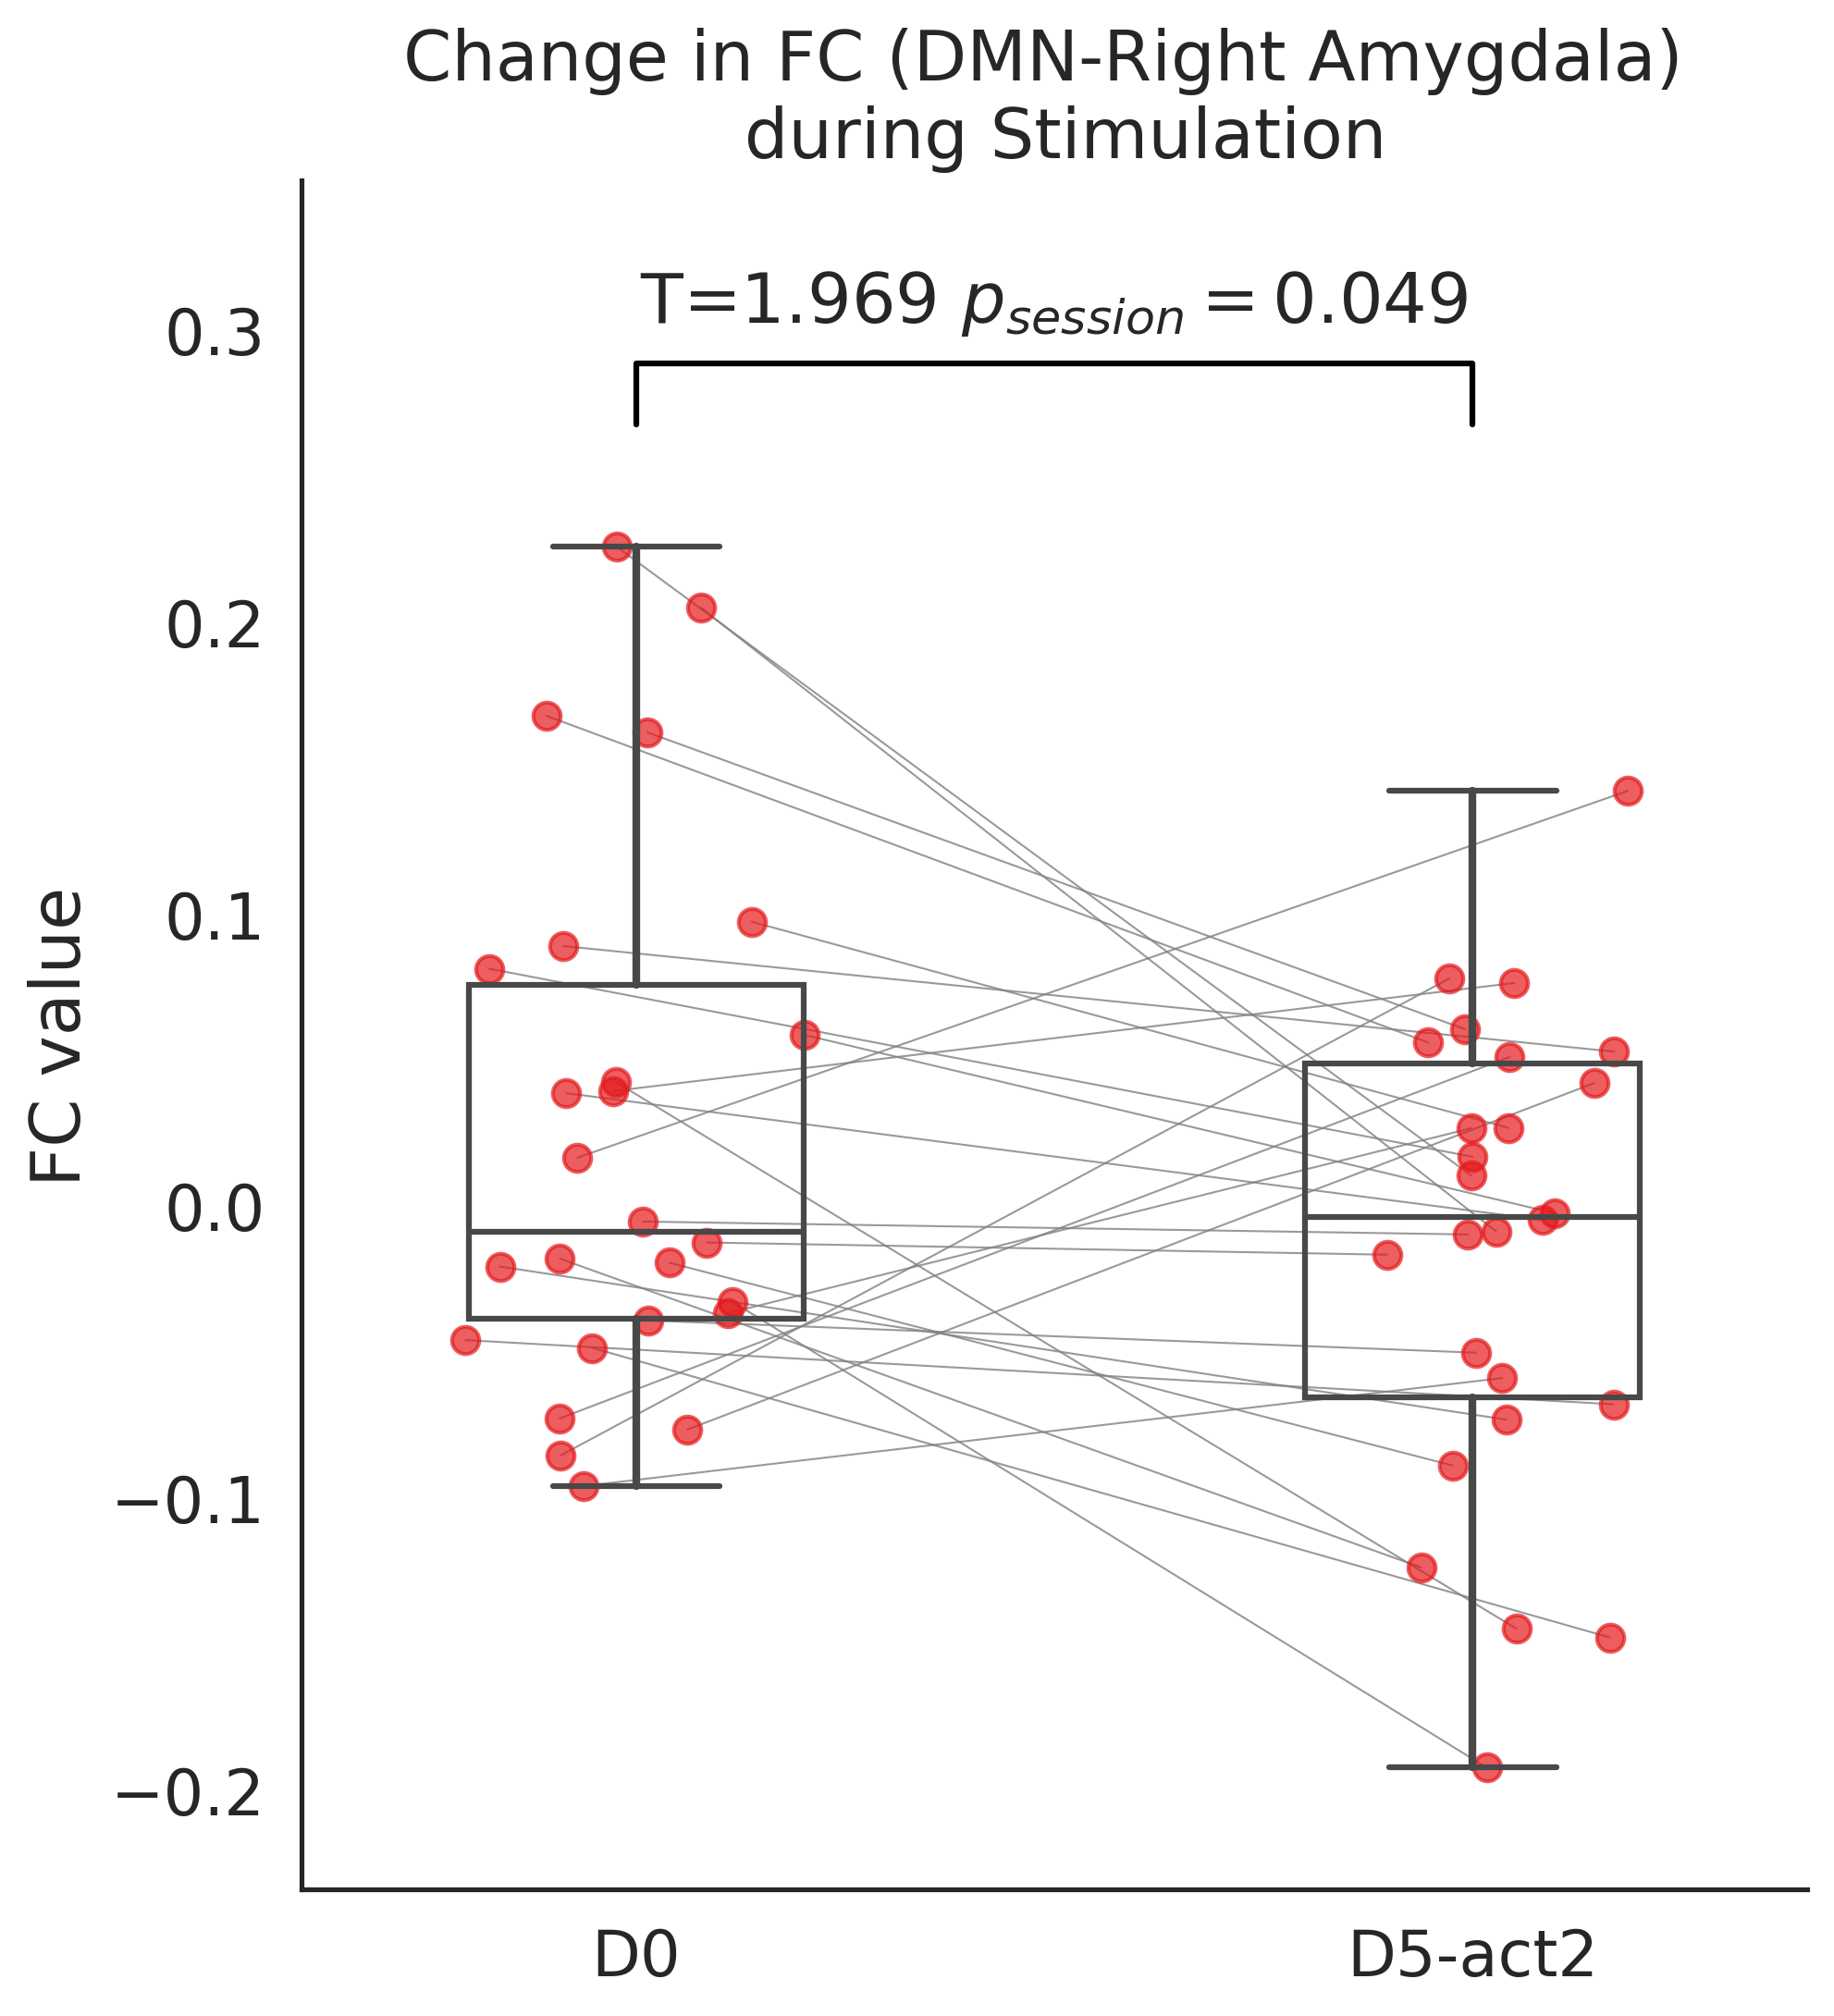

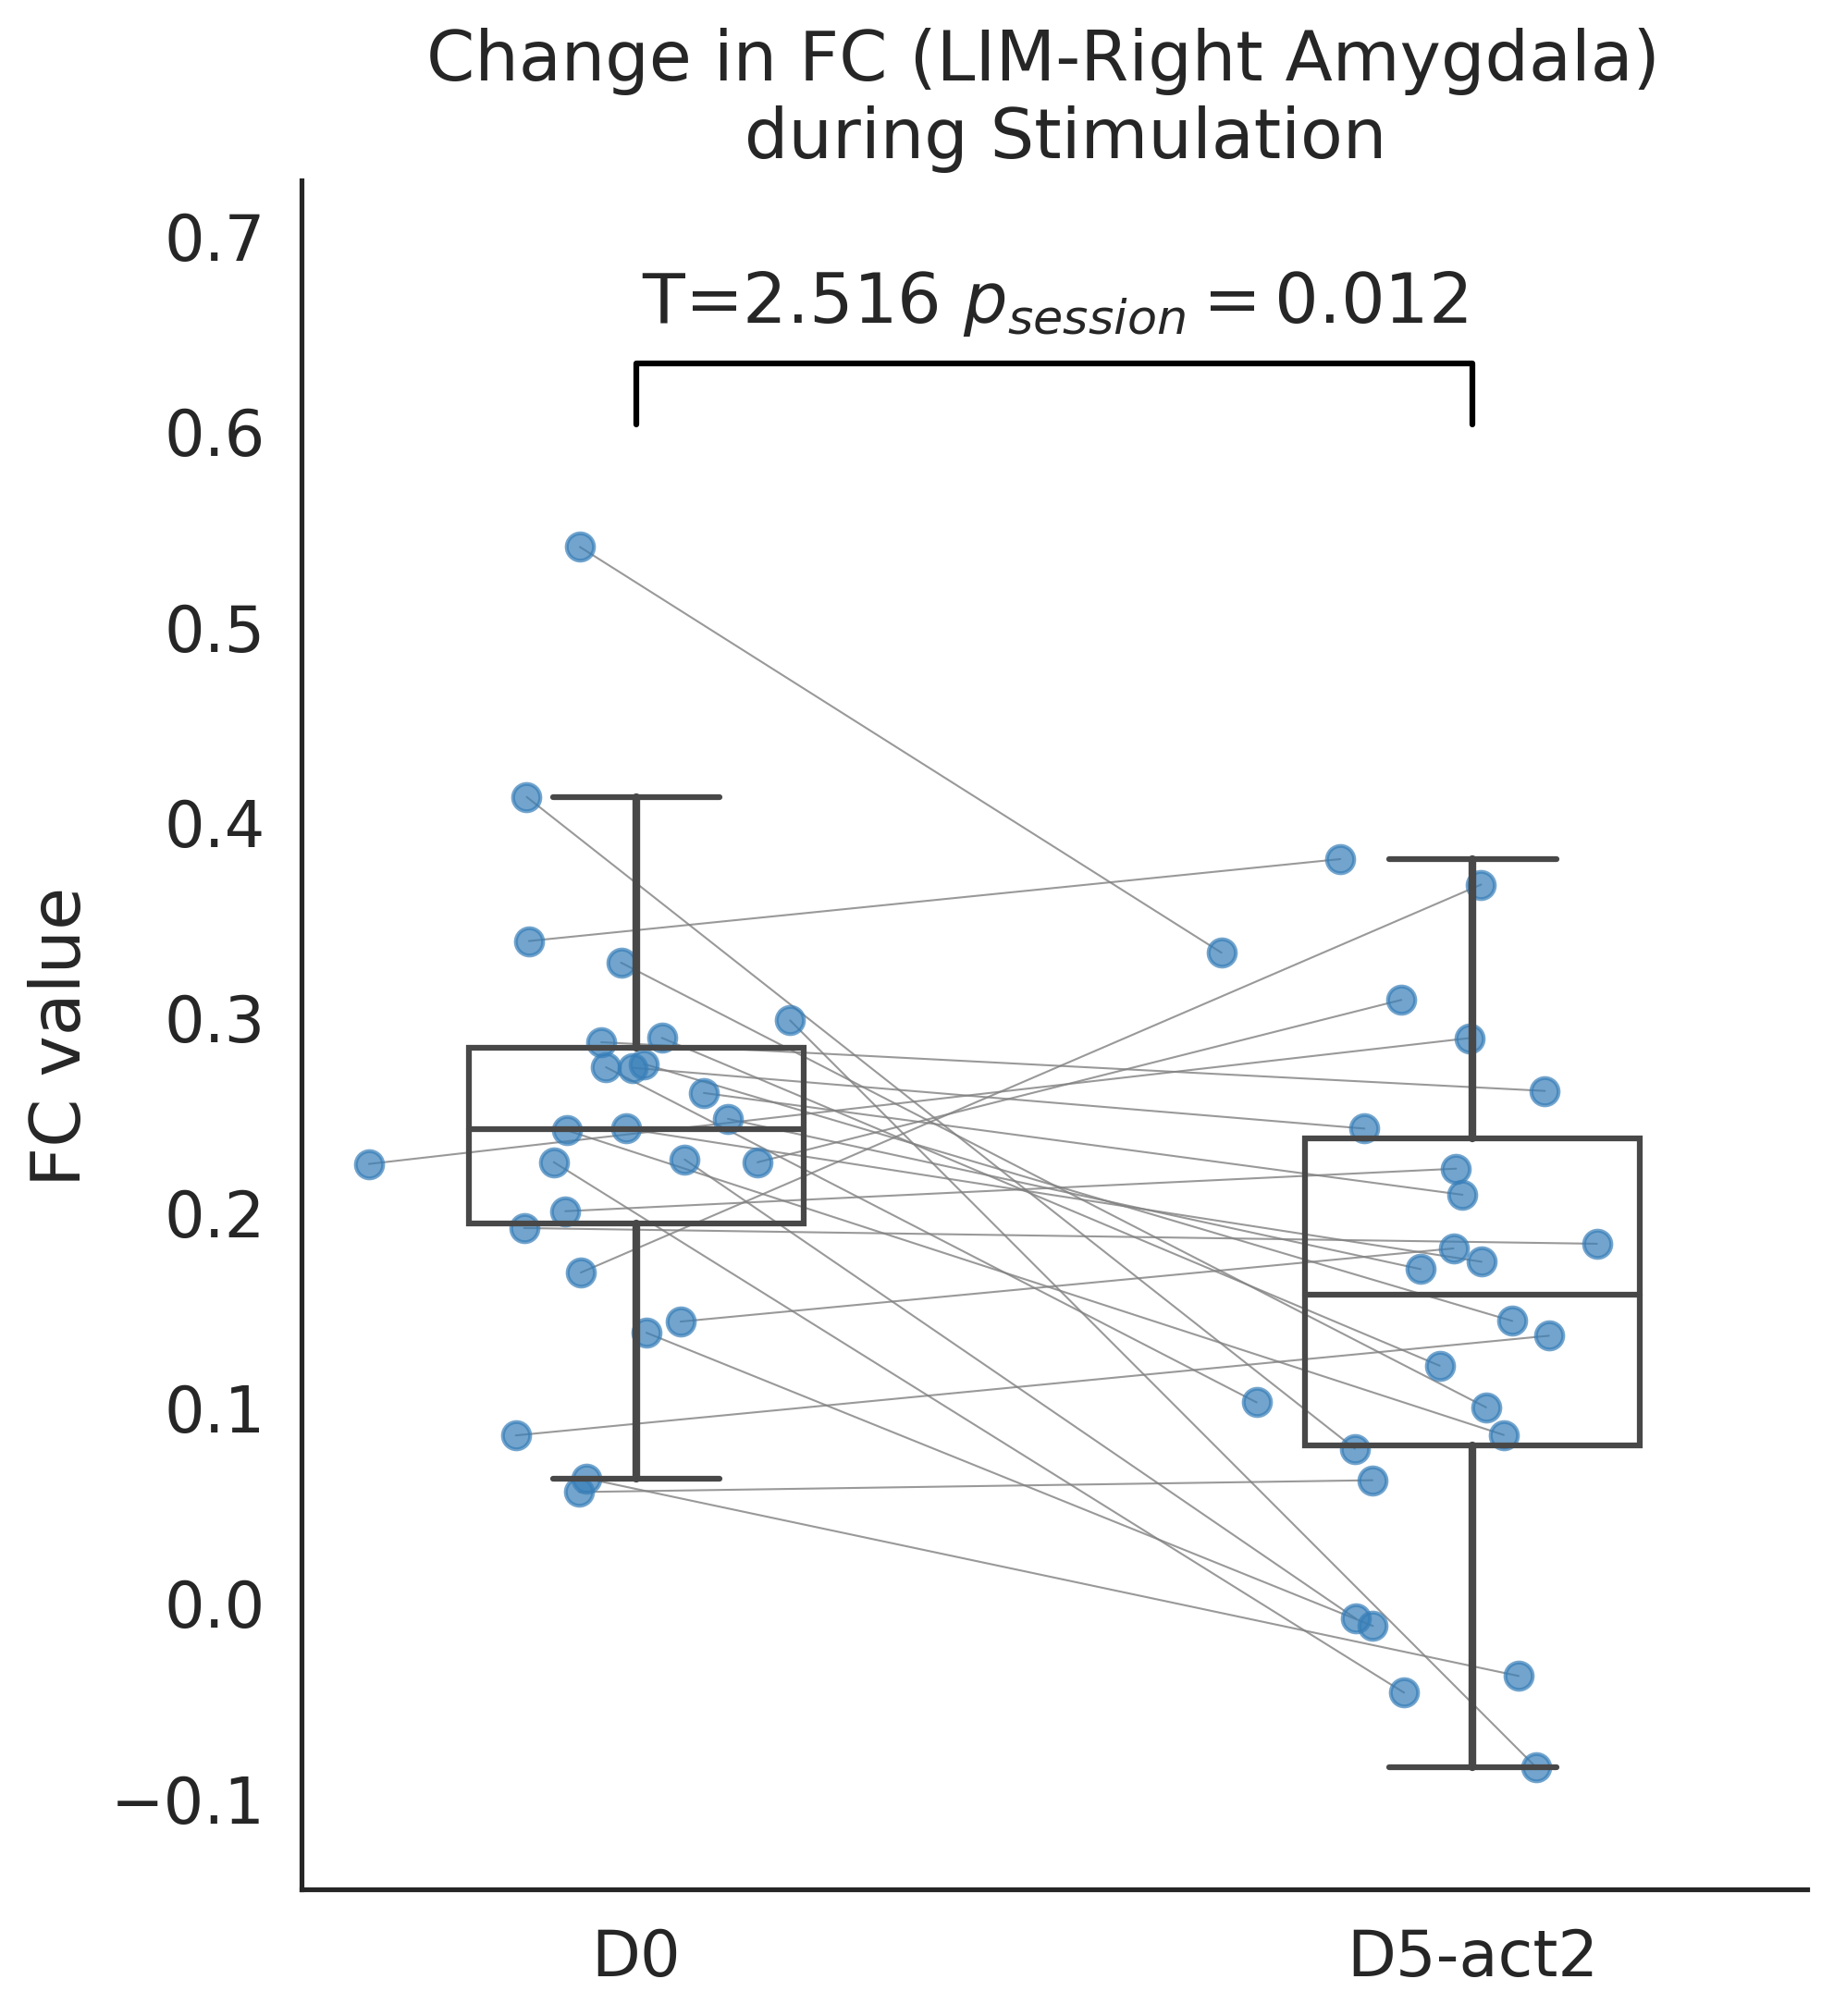

In [9]:
cmap = plt.get_cmap('Set1')

# Plot DMN-Right Amygdala FC change during the active stimulation session (5th_301)
ses = '5th_301'
rsn = 'Default'
p,T = result.loc[f"{ses}_{rsn}", ['p_ses','T_ses']]
df = fc_df[fc_df['ses'].isin(['baseline',ses])]

boxplotting(df = df,x_col = 'ses',y_col = rsn,order = ['baseline',ses],
            xticks = ['D0','D5-act2'],text=f"T={T:.3f} $p_{{session}}={p:.3f}$",colors = [cmap(0),cmap(0)],
            xlabel='',ylabel='FC value',title='Change in FC (DMN-Right Amygdala) \n during Stimulation')

# Plot Limbic-Right Amygdala FC change during the active stimulation session
ses = '5th_301'
rsn = 'Limbic'
p,T = result.loc[f"{ses}_{rsn}", ['p_ses','T_ses']]
df = fc_df[fc_df['ses'].isin(['baseline',ses])]

boxplotting(df = df,x_col = 'ses',y_col = rsn,order = ['baseline',ses],
            xticks = ['D0','D5-act2'],text=f"T={T:.3f} $p_{{session}}={p:.3f}$",colors = [cmap(1),cmap(1)],
            xlabel='',ylabel='FC value',title='Change in FC (LIM-Right Amygdala) \n during Stimulation')


In [10]:
# Extract short ROI name and hemisphere from Schaefer atlas labels (e.g., "Default_Temp_LEFT" → "Default_L")
def transform_subroi_name(roi):
    ls = re.split("_",roi)
    name = ls[0].title()
    hemi = 'L' if ls[-1]=='LEFT' else "R"
    return f"{name}_{hemi}"


In [11]:
# Load Schaefer atlas coordinates for cortical ROIs and AAL atlas for the amygdala
from nilearn import datasets
from nilearn.plotting import plot_connectome,find_parcellation_cut_coords

schaefer_atlas = datasets.fetch_atlas_schaefer_2018(n_rois = schaefer)
schaefer_coords = find_parcellation_cut_coords(schaefer_atlas['maps'])

aal_atlas = datasets.fetch_atlas_aal()
# Locate the Right Amygdala in the AAL atlas and get its MNI coordinate
Amygdala_R_idx = aal_atlas['labels'].index("Amygdala_R")
aal_coords = find_parcellation_cut_coords(aal_atlas['maps'])


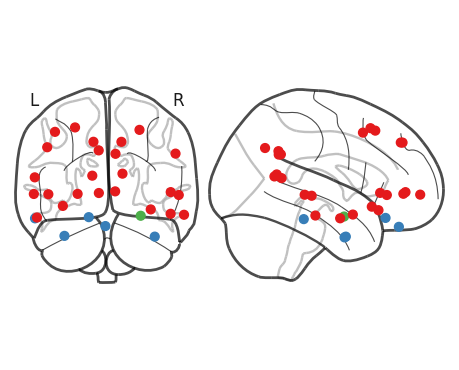

In [12]:
# Build coordinate array: Right Amygdala (seed) + Default + Limbic ROIs
coords = [aal_coords[Amygdala_R_idx]]
colors = [cmap(2)]

for i,rsn in enumerate(atlas['ICN']):
    if(rsn=='Default'):
        coords.append(schaefer_coords[i])
        colors.append(cmap(0))
    elif(rsn == 'Limbic'):
        coords.append(schaefer_coords[i])
        colors.append(cmap(1))
coords = np.array(coords)
colors = np.array(colors)
colors[:,-1] = 1  # Set full opacity

# Plot the connectome with nodes only (no edges) to visualize ROI locations
plot_connectome(
    adjacency_matrix = np.zeros((len(coords),len(coords))),
    node_coords = coords,
    node_color = colors,
    node_size = 40,
    display_mode = 'yx'
)
plt.savefig(f"amygdala_FC_{schaefer}",dpi = 300,bbox_inches='tight',pad_inches=0.1)
